In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [3]:
data_dir = "../data/processed"

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)
class_names = dataset.classes
class_names

['deer', 'skunk', 'turkey']

In [4]:
from torch.utils.data import random_split

# 80/20 split
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

len(train_dataset), len(val_dataset)

(100, 24)

In [5]:
class WildlifeCNN(nn.Module):
    def __init__(self):
        super(WildlifeCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [6]:
from torchvision import models
import torch.nn as nn

def create_resnet18_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = len(class_names)
model = create_resnet18_model(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\manni/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


In [8]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [8]:
epochs = 10
loss_history = []

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/10, Loss: 1.0377
Epoch 2/10, Loss: 0.6966
Epoch 3/10, Loss: 0.6384
Epoch 4/10, Loss: 0.3572
Epoch 5/10, Loss: 0.2116
Epoch 6/10, Loss: 0.2148
Epoch 7/10, Loss: 0.1724
Epoch 8/10, Loss: 0.1614
Epoch 9/10, Loss: 0.1501
Epoch 10/10, Loss: 0.0783


In [9]:
def evaluate(model, val_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

val_accuracy = evaluate(model, val_loader)
print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Accuracy: 87.50%


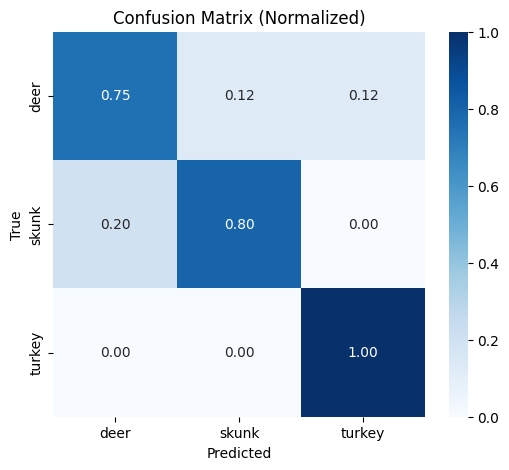

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Collect predictions and true labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, cmap='Blues', xticklabels=class_names, yticklabels=class_names, fmt=".2f")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")
plt.show()

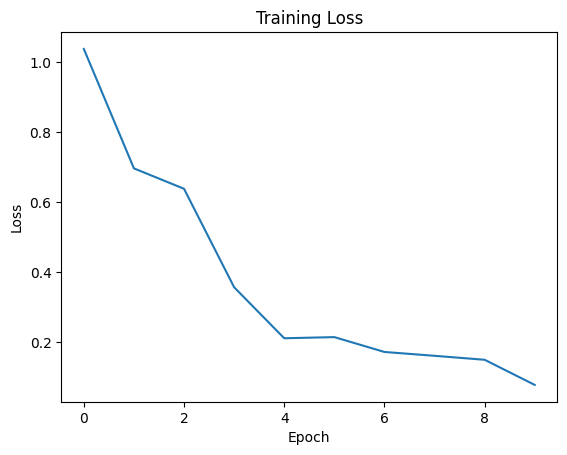

In [11]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [12]:
from PIL import Image

def predict_image(model, image_path, transform, class_names):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img_t = transform(img).unsqueeze(0)

    with torch.no_grad():
        outputs = model(img_t.to(device))
        _, predicted = torch.max(outputs, 1)

    return class_names[predicted.item()]

In [17]:
image_path = "C:\\Users\\manni\\Documents\\ai_wildlife_classifier\\data\\test_images\\deertest.jpg"
prediction = predict_image(model, image_path, transform, class_names)
prediction

'deer'

(-0.5, 1023.5, 682.5, -0.5)

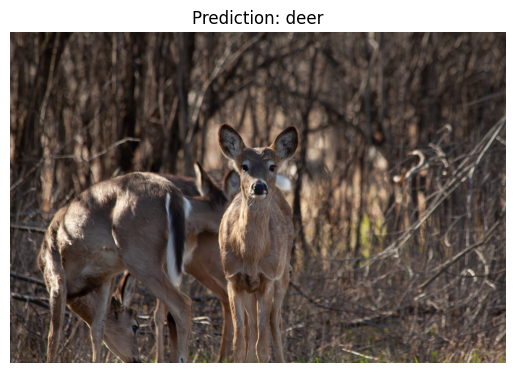

In [18]:
import matplotlib.pyplot as plt

img = Image.open(image_path)
plt.imshow(img)
plt.title(f"Prediction: {prediction}")
plt.axis("off")

In [ ]:
torch.save(model.state_dict(), "wildlife_classifier.pth")